In [1]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("✅ Done! Files:")
for f in os.listdir('.'):
    print(f)

✅ Done! Files:
.config
license.txt
googleplaystore.csv
archive (4).zip
googleplaystore_user_reviews.csv
sample_data


In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('googleplaystore.csv')

# Drop duplicates
df.drop_duplicates(inplace=True)

# Clean Installs → numeric
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Reviews → numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Last Updated → datetime
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Drop nulls
df.dropna(subset=['Installs', 'Reviews', 'Last Updated', 'Category', 'App'], inplace=True)

print("✅ Data loaded! Shape:", df.shape)
df.head()

✅ Data loaded! Shape: (10357, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up


In [3]:
# Filter 1: Category must start with E, C, or B
df = df[df['Category'].str.startswith(('E', 'C', 'B'))]

# Filter 2: App name should NOT start with X, Y, Z
df = df[~df['App'].str.startswith(('X', 'Y', 'Z'))]

# Filter 3: App name should NOT contain letter 'S'
df = df[~df['App'].str.contains('S', case=True)]

# Filter 4: Reviews > 500
df = df[df['Reviews'] > 500]

# Translate category names
translation_map = {
    'BEAUTY': 'सौंदर्य (Beauty)',
    'BUSINESS': 'வணிகம் (Business)',
    'DATING': 'Dating (Liebe)'
}
df['Category'] = df['Category'].replace(translation_map)

print("✅ Filters applied! Shape:", df.shape)
print("Categories found:", df['Category'].unique())

✅ Filters applied! Shape: (568, 13)
Categories found: ['सौंदर्य (Beauty)' 'BOOKS_AND_REFERENCE' 'வணிகம் (Business)' 'COMICS'
 'COMMUNICATION' 'EDUCATION' 'ENTERTAINMENT' 'EVENTS']


In [4]:
# Create Year-Month column
df['YearMonth'] = df['Last Updated'].dt.to_period('M')

# Group by YearMonth and Category → total installs
time_series = df.groupby(['YearMonth', 'Category'])['Installs'].sum().reset_index()
time_series['YearMonth'] = time_series['YearMonth'].dt.to_timestamp()

# Calculate month-over-month growth per category
time_series = time_series.sort_values(['Category', 'YearMonth'])
time_series['MoM_Growth'] = time_series.groupby('Category')['Installs'].pct_change() * 100

print("✅ Time series ready!")
print(time_series.head(10))

✅ Time series ready!
    YearMonth             Category    Installs    MoM_Growth
4  2014-07-01  BOOKS_AND_REFERENCE     50000.0           NaN
7  2014-10-01  BOOKS_AND_REFERENCE    500000.0    900.000000
8  2014-11-01  BOOKS_AND_REFERENCE   5000000.0    900.000000
10 2015-02-01  BOOKS_AND_REFERENCE     50000.0    -99.000000
15 2015-07-01  BOOKS_AND_REFERENCE  10000000.0  19900.000000
27 2016-06-01  BOOKS_AND_REFERENCE     60000.0    -99.400000
30 2016-08-01  BOOKS_AND_REFERENCE    100000.0     66.666667
37 2016-12-01  BOOKS_AND_REFERENCE    500000.0    400.000000
41 2017-02-01  BOOKS_AND_REFERENCE    100000.0    -80.000000
42 2017-03-01  BOOKS_AND_REFERENCE    100000.0      0.000000


Current IST hour: 18


/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2380 (\N{DEVANAGARI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2306 (\N{DEVANAGARI SIGN ANUSVARA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2342 (\N{DEVANAGARI LETTER DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1897/194753493.py:48: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

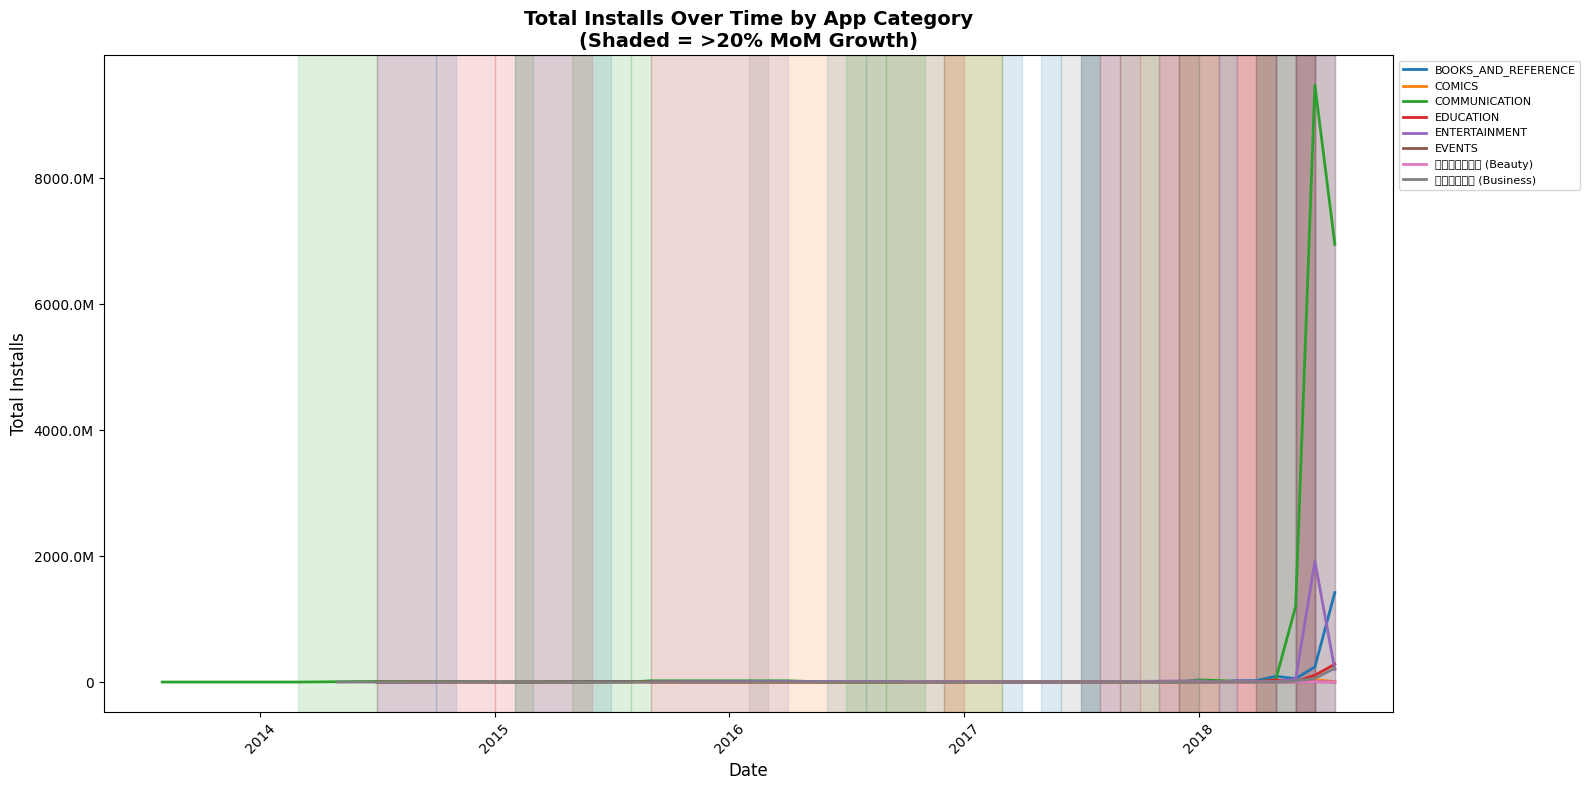

✅ Chart saved as task4_timeseries.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime
import pytz

# Check current IST time
ist = pytz.timezone('Asia/Kolkata')
current_hour = datetime.now(ist).hour

print(f"Current IST hour: {current_hour}")

if not (18 <= current_hour < 21):
    print("⛔ Chart is only available between 6 PM and 9 PM IST. Please come back then.")

else:
    categories = time_series['Category'].unique()
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, cat in enumerate(categories):
        cat_data = time_series[time_series['Category'] == cat].copy()
        cat_data = cat_data.sort_values('YearMonth')

        # Plot line
        ax.plot(cat_data['YearMonth'], cat_data['Installs'],
                label=cat, color=colors[i % len(colors)], linewidth=2)

        # Shade areas where MoM growth > 20%
        for j in range(1, len(cat_data)):
            if cat_data['MoM_Growth'].iloc[j] > 20:
                ax.axvspan(
                    cat_data['YearMonth'].iloc[j-1],
                    cat_data['YearMonth'].iloc[j],
                    alpha=0.15,
                    color=colors[i % len(colors)]
                )

    ax.set_title('Total Installs Over Time by App Category\n(Shaded = >20% MoM Growth)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Total Installs', fontsize=12)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f'{val/1e6:.1f}M' if val >= 1e6 else f'{int(val):,}')
    )
    ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('task4_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Chart saved as task4_timeseries.png")